In [7]:
import pandas as pd
import time
from datetime import datetime, timedelta
from pathlib import Path
import re
import shutil

COLUMNS = [
    "回号",
    "抽せん日",
    "当選番号",
    "ストレート",
    "ボックス",
    "セット（ストレート）",
    "セット（ボックス）",
    "ミニ",
    "販売実績額",
]
PAYOUT_COLUMNS = COLUMNS[3:]

ALIAS_MAP = {
    "当せん番号": "当選番号",
    "抽選日": "抽せん日",
}


def normalize_numbers3_columns(df):
    df = df.copy()
    for old, new in ALIAS_MAP.items():
        if old in df.columns:
            if new in df.columns:
                df[new] = df[new].fillna(df[old])
                df = df.drop(columns=[old])
            else:
                df = df.rename(columns={old: new})
    return df


def _clean_digits(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    digits = re.sub(r"[^0-9]", "", str(value))
    return digits if digits else None


def _normalize_winning_number_series(series):
    cleaned = series.apply(_clean_digits)
    return cleaned.apply(lambda x: x.zfill(3) if isinstance(x, str) else None)


def _normalize_record(record):
    row = {}

    round_raw = record.get("回号")
    round_digits = _clean_digits(round_raw)
    if round_digits:
        row["回号"] = round_digits.zfill(4)

    draw_date = record.get("抽せん日") or record.get("抽選日")
    if draw_date:
        row["抽せん日"] = str(draw_date).strip()

    win_raw = record.get("当選番号") or record.get("当せん番号")
    win_digits = _clean_digits(win_raw)
    if win_digits:
        row["当選番号"] = win_digits.zfill(3)

    for key in PAYOUT_COLUMNS:
        val = record.get(key)
        digits = _clean_digits(val)
        if digits is not None:
            row[key] = int(digits)

    return row


def _col_contains(columns, text):
    return any(text in str(c) for c in columns)


def _extract_round_from_columns(columns):
    for col in columns[1:]:
        digits = _clean_digits(col)
        if digits:
            return digits
    return None


def _table_to_records(df):
    records = []
    df_work = df.copy()
    df_work.columns = [str(c).strip() for c in df_work.columns]

    if not df_work.empty and _col_contains(df_work.columns, "回号"):
        if _col_contains(df_work.columns, "当選番号") or _col_contains(df_work.columns, "当せん番号"):
            for _, row in df_work.iterrows():
                records.append(row.to_dict())
            return records

    if not df_work.empty:
        header = [str(v).strip() for v in df_work.iloc[0].tolist()]
        if _col_contains(header, "回号") and (_col_contains(header, "当選番号") or _col_contains(header, "当せん番号")):
            df_work = df_work.iloc[1:].copy()
            df_work.columns = header
            for _, row in df_work.iterrows():
                records.append(row.to_dict())
            return records

    if df_work.shape[1] >= 2:
        record = dict(zip(df_work.iloc[:, 0], df_work.iloc[:, 1]))
        round_digits = _extract_round_from_columns(df_work.columns)
        if round_digits:
            record["回号"] = round_digits
        records.append(record)
    return records


def fetch_numbers3_by_month(start_date, end_date, sleep_seconds=1):
    rows = []
    current = datetime(start_date.year, start_date.month, 1)
    last_month = datetime(end_date.year, end_date.month, 1)

    while current <= last_month:
        yyyymm = current.strftime("%Y%m")
        url = f"https://takarakuji.rakuten.co.jp/backnumber/numbers3/{yyyymm}/"
        print(f"取得中: {yyyymm}...")

        try:
            tables = pd.read_html(url, header=0)
            for df in tables:
                records = _table_to_records(df)
                for record in records:
                    if "当選番号" not in record and "当せん番号" not in record:
                        continue
                    row = _normalize_record(record)
                    if row.get("回号") and row.get("当選番号"):
                        rows.append(row)
            time.sleep(sleep_seconds)
        except Exception as e:
            print(f"スキップ ({yyyymm}): {e}")

        current = (current.replace(day=28) + timedelta(days=4)).replace(day=1)

    return pd.DataFrame(rows)


def _coverage_ratio(df):
    if "回号" not in df.columns:
        return None
    rounds = pd.to_numeric(df["回号"], errors="coerce").dropna().astype(int)
    if rounds.empty:
        return None
    min_r, max_r = rounds.min(), rounds.max()
    total_range = max_r - min_r + 1
    if total_range <= 0:
        return None
    return rounds.nunique() / total_range


def update_numbers3_clean(
    clean_path="numbers3_clean.csv",
    backup=True,
    sleep_seconds=1,
    force_full=False,
 ):
    path = Path(clean_path)
    if path.exists() and not force_full:
        df_existing = pd.read_csv(path)
        df_existing = normalize_numbers3_columns(df_existing)
        if "当選番号" in df_existing.columns:
            df_existing["当選番号"] = _normalize_winning_number_series(df_existing["当選番号"])
    else:
        df_existing = pd.DataFrame(columns=COLUMNS)

    if force_full:
        start_date = datetime(1994, 10, 1)
    else:
        coverage = _coverage_ratio(df_existing)
        if coverage is not None and coverage < 0.9:
            print("既存データが疎なため、全期間を再取得します。")
            df_existing = pd.DataFrame(columns=COLUMNS)
            start_date = datetime(1994, 10, 1)
        elif not df_existing.empty and "抽せん日" in df_existing.columns:
            dates = pd.to_datetime(df_existing["抽せん日"], errors="coerce")
            last_date = dates.max()
            if pd.isna(last_date):
                start_date = datetime(1994, 10, 1)
            else:
                start_date = datetime(last_date.year, last_date.month, 1)
        else:
            start_date = datetime(1994, 10, 1)

    new_df = fetch_numbers3_by_month(start_date, datetime.now(), sleep_seconds=sleep_seconds)
    new_df = normalize_numbers3_columns(new_df)
    if "当選番号" in new_df.columns:
        new_df["当選番号"] = _normalize_winning_number_series(new_df["当選番号"])

    if new_df.empty:
        print("新規データなし。")
        return df_existing

    combined = pd.concat([df_existing, new_df], ignore_index=True)
    combined = normalize_numbers3_columns(combined)
    if "当選番号" in combined.columns:
        combined["当選番号"] = _normalize_winning_number_series(combined["当選番号"])
    if "回号" in combined.columns:
        combined["回号"] = combined["回号"].astype(str).str.zfill(4)
        combined = combined.drop_duplicates(subset=["回号"], keep="last")
        combined = combined.sort_values(by="回号", key=lambda s: s.astype(int))

    ordered_cols = [c for c in COLUMNS if c in combined.columns]
    if ordered_cols:
        combined = combined[ordered_cols]

    if backup and path.exists():
        backup_path = path.with_suffix(path.suffix + ".bak")
        shutil.copy2(path, backup_path)
        print(f"バックアップ保存: {backup_path}")

    combined.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"更新完了: {len(combined)}件を {path.name} に保存しました。")
    return combined


def backfill_numbers3_range(clean_path, start_date, end_date, backup=True, sleep_seconds=1):
    path = Path(clean_path)
    if path.exists():
        df_existing = pd.read_csv(path)
        df_existing = normalize_numbers3_columns(df_existing)
        if "当選番号" in df_existing.columns:
            df_existing["当選番号"] = _normalize_winning_number_series(df_existing["当選番号"])
    else:
        df_existing = pd.DataFrame(columns=COLUMNS)

    new_df = fetch_numbers3_by_month(start_date, end_date, sleep_seconds=sleep_seconds)
    new_df = normalize_numbers3_columns(new_df)
    if "当選番号" in new_df.columns:
        new_df["当選番号"] = _normalize_winning_number_series(new_df["当選番号"])

    combined = pd.concat([df_existing, new_df], ignore_index=True)
    combined = normalize_numbers3_columns(combined)
    if "当選番号" in combined.columns:
        combined["当選番号"] = _normalize_winning_number_series(combined["当選番号"])
    if "回号" in combined.columns:
        combined["回号"] = combined["回号"].astype(str).str.zfill(4)
        combined = combined.drop_duplicates(subset=["回号"], keep="last")
        combined = combined.sort_values(by="回号", key=lambda s: s.astype(int))

    ordered_cols = [c for c in COLUMNS if c in combined.columns]
    if ordered_cols:
        combined = combined[ordered_cols]

    if backup and path.exists():
        backup_path = path.with_suffix(path.suffix + ".bak")
        shutil.copy2(path, backup_path)
        print(f"バックアップ保存: {backup_path}")

    combined.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"更新完了: {len(combined)}件を {path.name} に保存しました。")
    return combined


def validate_numbers3(df, strict=True, allow_missing_rounds=True):
    errors = []
    warnings = []
    df = normalize_numbers3_columns(df)
    if "当選番号" in df.columns:
        df["当選番号"] = _normalize_winning_number_series(df["当選番号"])

    if "回号" in df.columns:
        rounds = df["回号"].astype(str)
        round_nums = pd.to_numeric(rounds, errors="coerce")
        if round_nums.isna().any():
            errors.append("回号に数値化できない値があります。")
        else:
            round_nums = round_nums.astype(int)
            duplicates = rounds[rounds.duplicated()].unique().tolist()
            if duplicates:
                errors.append(f"回号の重複: {duplicates[:10]}")

            if not round_nums.empty:
                min_r, max_r = round_nums.min(), round_nums.max()
                missing = sorted(set(range(min_r, max_r + 1)) - set(round_nums))
                if missing:
                    message = f"回号の欠番: {missing[:10]}"
                    if allow_missing_rounds:
                        warnings.append(message)
                    else:
                        errors.append(message)

    if "当選番号" in df.columns:
        invalid = df[df["当選番号"].isna() | ~df["当選番号"].astype(str).str.fullmatch(r"\d{3}")]
        if not invalid.empty:
            errors.append("当選番号が3桁でない行があります。")

    if errors and strict:
        raise ValueError(" / ".join(errors))

    if errors:
        print("警告:", " / ".join(errors))
    if warnings:
        print("注意:", " / ".join(warnings))

    return errors + warnings


class Numbers3FeatureEngineer:
    def __init__(self, window=20):
        self.window = window

    def add_features(self, df):
        df = normalize_numbers3_columns(df)
        df = df.copy().reset_index(drop=True)
        if "当選番号" not in df.columns:
            return df

        num = df["当選番号"].astype(str).str.zfill(3)
        df["digit_h"] = num.str[0].astype(int)
        df["digit_t"] = num.str[1].astype(int)
        df["digit_o"] = num.str[2].astype(int)

        df["digit_sum"] = df[["digit_h", "digit_t", "digit_o"]].sum(axis=1)
        df["odd_count"] = (df[["digit_h", "digit_t", "digit_o"]] % 2 == 1).sum(axis=1)
        df["even_count"] = 3 - df["odd_count"]
        df["small_count"] = (df[["digit_h", "digit_t", "digit_o"]] <= 4).sum(axis=1)
        df["big_count"] = 3 - df["small_count"]

        df["delta_prev"] = df["当選番号"].astype(int).diff()
        df["sum_ma_20"] = df["digit_sum"].rolling(self.window, min_periods=1).mean()

        rolling_prob = (
            df["digit_h"]
            .rolling(self.window, min_periods=1)
            .apply(lambda x: (x == x.iloc[-1]).mean(), raw=False)
        )
        df["hundreds_prob_window"] = rolling_prob

        return df

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import font_manager


def configure_japanese_fonts():
    preferred = [
        "IPAexGothic",
        "IPAexMincho",
        "Noto Sans CJK JP",
        "Yu Gothic",
        "Meiryo",
        "MS Gothic",
    ]
    available = {font.name for font in font_manager.fontManager.ttflist}
    for name in preferred:
        if name in available:
            mpl.rcParams["font.family"] = name
            mpl.rcParams["axes.unicode_minus"] = False
            return name
    mpl.rcParams["axes.unicode_minus"] = False
    return None


_selected_font = configure_japanese_fonts()
if _selected_font is None:
    print("日本語フォントが見つからないため、タイトルが豆腐になる可能性があります。")


class Numbers3IntervalAnalyzer:
    def __init__(self, df):
        self.df = df.copy()
        self._ensure_digit_columns()
        if "回号" in self.df.columns:
            self.df["回号"] = pd.to_numeric(self.df["回号"], errors="coerce")
        self.df = self.df.sort_values("回号").copy()

    def _ensure_digit_columns(self):
        if "digit_h" in self.df.columns:
            return
        if "当選番号" not in self.df.columns:
            if "当せん番号" in self.df.columns:
                self.df["当選番号"] = self.df["当せん番号"]
            else:
                raise KeyError("当選番号が存在しないため、digit_hを作成できません。")
        num = self.df["当選番号"].astype(str).str.zfill(3)
        self.df["digit_h"] = num.str[0].astype(int)
        self.df["digit_t"] = num.str[1].astype(int)
        self.df["digit_o"] = num.str[2].astype(int)

    def calculate_intervals(self, column="digit_h"):
        intervals = {i: [] for i in range(10)}
        for num in range(10):
            appearance_indices = self.df[self.df[column] == num]["回号"].dropna().values
            if len(appearance_indices) > 1:
                intervals[num] = np.diff(appearance_indices)
        return intervals

    def plot_interval_analysis(self, column="digit_h"):
        intervals_dict = self.calculate_intervals(column)
        all_intervals = [item for sublist in intervals_dict.values() for item in sublist]

        if len(all_intervals) == 0:
            print("インターバルが計算できませんでした。")
            return

        plt.figure(figsize=(12, 6))
        sns.histplot(all_intervals, bins=50, kde=True, color="skyblue")
        plt.axvline(np.mean(all_intervals), color="red", linestyle="--", label=f"平均: {np.mean(all_intervals):.1f}回")
        plt.title(f"数字出現インターバルの分布 ({column})")
        plt.xlabel("ハマリ回数（回）")
        plt.ylabel("頻度")
        plt.legend()
        plt.grid(axis="y", alpha=0.3)
        plt.show()

        sorted_intervals = np.sort(all_intervals)
        yvals = np.arange(len(sorted_intervals)) / float(len(sorted_intervals) - 1)

        plt.figure(figsize=(12, 6))
        plt.plot(sorted_intervals, yvals, marker=".", linestyle="none", color="navy")
        plt.axhline(0.90, color="orange", linestyle="--", label="90% 累積ライン")
        plt.title(f"ハマリ回数の累積分布 ({column})")
        plt.xlabel("ハマリ回数（回）")
        plt.ylabel("累積確率")

        idx90 = np.where(yvals >= 0.90)[0][0]
        val90 = sorted_intervals[idx90]
        plt.axvline(val90, color="orange", linestyle="--")
        plt.annotate(f"90%が{val90}回以内に再出現", xy=(val90, 0.5), color="darkorange", fontweight="bold")

        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


class Numbers3TrendAnalyzer:
    def __init__(self, df):
        self.df = df.copy()
        self._ensure_sum_features()
        if "回号" in self.df.columns:
            self.df["回号"] = pd.to_numeric(self.df["回号"], errors="coerce")
        self.df = self.df.sort_values("回号").dropna(subset=["回号"]).copy()

    def _ensure_sum_features(self):
        if "digit_sum" in self.df.columns:
            return
        if "当選番号" not in self.df.columns:
            if "当せん番号" in self.df.columns:
                self.df["当選番号"] = self.df["当せん番号"]
            else:
                raise KeyError("当選番号が存在しないため、digit_sumを作成できません。")
        num = self.df["当選番号"].astype(str).str.zfill(3)
        self.df["digit_h"] = num.str[0].astype(int)
        self.df["digit_t"] = num.str[1].astype(int)
        self.df["digit_o"] = num.str[2].astype(int)
        self.df["digit_sum"] = self.df[["digit_h", "digit_t", "digit_o"]].sum(axis=1)

    def get_theoretical_probs(self):
        p = np.ones(10) / 10.0
        p_sum = np.convolve(p, p)
        p_sum = np.convolve(p_sum, p)
        return p_sum

    def plot_sum_distribution(self):
        sums = self.df["digit_sum"]

        plt.figure(figsize=(12, 6))
        sns.histplot(
            sums,
            bins=np.arange(29) - 0.5,
            kde=False,
            stat="density",
            color="green",
            alpha=0.6,
            label="実際の出現頻度",
        )

        theoretical_probs = self.get_theoretical_probs()
        x = np.arange(28)
        plt.plot(x, theoretical_probs, "r-o", linewidth=2, markersize=5, label="理論上の確率 (厳密解)")

        plt.title("当選番号合計値の分布分析")
        plt.xlabel("合計値 (0〜27)")
        plt.ylabel("確率")
        plt.legend()
        plt.grid(axis="y", alpha=0.3)
        plt.xticks(range(0, 28, 2))
        plt.show()

    def plot_moving_average_trend(self, window=50):
        ma = self.df["digit_sum"].rolling(window=window).mean()

        plt.figure(figsize=(15, 6))
        plt.plot(self.df["回号"], ma, color="blue", linewidth=1, label=f"{window}回移動平均")
        plt.axhline(13.5, color="red", linestyle="--", label="理論的な期待値 (13.5)")

        valid_indices = ~np.isnan(ma)
        x_valid = self.df["回号"][valid_indices]
        y_valid = ma[valid_indices]

        plt.fill_between(x_valid, y_valid, 13.5, where=(y_valid > 13.5), color="red", alpha=0.1)
        plt.fill_between(x_valid, y_valid, 13.5, where=(y_valid < 13.5), color="blue", alpha=0.1)

        plt.title(f"合計値の移動平均トレンド ({window}回移動平均)")
        plt.xlabel("回号")
        plt.ylabel("合計値の平均")
        plt.legend(loc="upper left")
        plt.grid(alpha=0.3)
        plt.show()


class Numbers3PatternAnalyzer:
    def __init__(self, df):
        self.df = df.copy()
        self._ensure_pattern_features()
        if "回号" in self.df.columns:
            self.df["回号"] = pd.to_numeric(self.df["回号"], errors="coerce")
        self.df = self.df.sort_values("回号").dropna(subset=["回号"]).copy()

    def _ensure_pattern_features(self):
        if "odd_count" in self.df.columns and "big_count" in self.df.columns:
            return
        if "当選番号" not in self.df.columns:
            if "当せん番号" in self.df.columns:
                self.df["当選番号"] = self.df["当せん番号"]
            else:
                raise KeyError("当選番号が存在しないため、odd_countを作成できません。")
        num = self.df["当選番号"].astype(str).str.zfill(3)
        self.df["digit_h"] = num.str[0].astype(int)
        self.df["digit_t"] = num.str[1].astype(int)
        self.df["digit_o"] = num.str[2].astype(int)
        self.df["odd_count"] = (self.df[["digit_h", "digit_t", "digit_o"]] % 2 == 1).sum(axis=1)
        self.df["big_count"] = (self.df[["digit_h", "digit_t", "digit_o"]] >= 5).sum(axis=1)

    def plot_transition_heatmap(self, column="odd_count", title=None):
        data = pd.DataFrame({
            "current": self.df[column],
            "next": self.df[column].shift(-1),
        }).dropna()

        cross_tab = pd.crosstab(data["current"], data["next"], normalize="index")

        plt.figure(figsize=(8, 6))
        sns.heatmap(cross_tab, annot=True, cmap="Blues", fmt=".2%")

        display_title = title if title else f"{column} の遷移確率（現在 -> 次回）"
        plt.title(display_title)
        plt.xlabel("次回の状態")
        plt.ylabel("現在の状態")
        plt.show()


class Numbers3Predictor:
    def __init__(self, df):
        self.df = df.copy()
        self._ensure_features()
        if "回号" in self.df.columns:
            self.df["回号"] = pd.to_numeric(self.df["回号"], errors="coerce")
        self.df = self.df.sort_values("回号").dropna(subset=["回号"]).reset_index(drop=True)

    def _ensure_features(self):
        if "当選番号" not in self.df.columns:
            if "当せん番号" in self.df.columns:
                self.df["当選番号"] = self.df["当せん番号"]
            else:
                raise KeyError("当選番号（または当せん番号）列が必要です。")

        num = self.df["当選番号"].astype(str).str.zfill(3)
        self.df["digit_h"] = num.str[0].astype(int)
        self.df["digit_t"] = num.str[1].astype(int)
        self.df["digit_o"] = num.str[2].astype(int)

        self.df["odd_count"] = (self.df[["digit_h", "digit_t", "digit_o"]] % 2 == 1).sum(axis=1)
        self.df["big_count"] = (self.df[["digit_h", "digit_t", "digit_o"]] >= 5).sum(axis=1)
        self.df["digit_sum"] = self.df[["digit_h", "digit_t", "digit_o"]].sum(axis=1)

    def _get_transition_matrix(self, column):
        current = self.df[column]
        nxt = self.df[column].shift(-1)
        return pd.crosstab(current, nxt, normalize="index")

    def _get_digit_intervals(self):
        intervals = {"digit_h": {}, "digit_t": {}, "digit_o": {}}
        last_index = self.df.index[-1]

        for col in ["digit_h", "digit_t", "digit_o"]:
            for n in range(10):
                series = self.df[col]
                locs = series[series == n].index
                if len(locs) > 0:
                    last_occurrence = locs[-1]
                    gap = last_index - last_occurrence
                else:
                    gap = len(self.df)
                intervals[col][n] = gap
        return intervals

    def _get_sum_probabilities(self):
        p = np.ones(10) / 10.0
        p_sum = np.convolve(p, p)
        p_sum = np.convolve(p_sum, p)
        return p_sum

    def predict(self, top_n=20):
        trans_odd = self._get_transition_matrix("odd_count")
        trans_big = self._get_transition_matrix("big_count")

        last_row = self.df.iloc[-1]
        current_odd = last_row["odd_count"]
        current_big = last_row["big_count"]
        current_num = last_row["当選番号"]
        print(f"直近の結果: 回号={last_row['回号']}, 番号={current_num}, 奇数={current_odd}個, Big={current_big}個")

        intervals = self._get_digit_intervals()
        sum_probs = self._get_sum_probabilities()

        candidates = []
        for n in range(1000):
            s_num = f"{n:03d}"
            h = int(s_num[0])
            t = int(s_num[1])
            o = int(s_num[2])

            c_sum = h + t + o
            c_odd = (h % 2) + (t % 2) + (o % 2)
            c_big = (1 if h >= 5 else 0) + (1 if t >= 5 else 0) + (1 if o >= 5 else 0)

            try:
                prob_odd_trans = trans_odd.loc[current_odd, c_odd]
            except KeyError:
                prob_odd_trans = 0

            try:
                prob_big_trans = trans_big.loc[current_big, c_big]
            except KeyError:
                prob_big_trans = 0

            pattern_score = prob_odd_trans * prob_big_trans
            sum_score = sum_probs[c_sum]

            total_gap = intervals["digit_h"][h] + intervals["digit_t"][t] + intervals["digit_o"][o]
            interval_bonus = 1.0 + np.log1p(total_gap) * 0.1

            final_score = pattern_score * sum_score * interval_bonus

            candidates.append({
                "予測番号": s_num,
                "総合スコア": final_score,
                "パターン確率": pattern_score,
                "合計値確率": sum_score,
                "ハマリ係数": interval_bonus,
                "直前ギャップ和": total_gap,
                "合計": c_sum,
                "奇数数": c_odd,
                "Big数": c_big,
            })

        df_pred = pd.DataFrame(candidates)
        df_pred = df_pred.sort_values("総合スコア", ascending=False).reset_index(drop=True)

        if not df_pred.empty:
            max_score = df_pred["総合スコア"].max()
            if max_score > 0:
                df_pred["総合スコア"] = (df_pred["総合スコア"] / max_score * 100.0).round(1)

        return df_pred.head(top_n)


def _box_key(number_str):
    return "".join(sorted(number_str))


class Numbers3Backtester:
    def __init__(self, df, engineer, window=200, top_n=50):
        self.df = df.sort_values("回号").reset_index(drop=True)
        self.fe = engineer
        self.window = window
        self.top_n = top_n

    def _prepare_features(self, df_slice):
        if "digit_h" in df_slice.columns and "sum_ma_20" in df_slice.columns:
            return df_slice
        return self.fe.add_features(df_slice)

    def run(self, test_rounds=50, top_k_list=(10, 50, 100)):
        results = []
        total = min(test_rounds, len(self.df) - 2)
        for i in range(total):
            train_end = len(self.df) - 2 - i
            train_start = max(0, train_end - self.window)
            train_df = self.df.iloc[train_start:train_end + 1].copy()
            train_df = self._prepare_features(train_df)

            actual_row = self.df.iloc[train_end + 1]
            actual_num = str(actual_row["当選番号"]).zfill(3)
            actual_box = _box_key(actual_num)

            predictor = Numbers3Predictor(train_df)
            pred_df = predictor.predict(top_n=self.top_n)
            ranked_nums = pred_df["予測番号"].tolist()
            ranked_boxes = [_box_key(n) for n in ranked_nums]

            rank_st = ranked_nums.index(actual_num) + 1 if actual_num in ranked_nums else None
            rank_box = ranked_boxes.index(actual_box) + 1 if actual_box in ranked_boxes else None

            hit_topk = {f"st_top{k}": (rank_st is not None and rank_st <= k) for k in top_k_list}
            hit_topk.update({f"box_top{k}": (rank_box is not None and rank_box <= k) for k in top_k_list})

            results.append({
                "target_round": int(actual_row["回号"]) if pd.notna(actual_row["回号"]) else None,
                "actual": actual_num,
                "rank_st": rank_st,
                "rank_box": rank_box,
                **hit_topk,
            })

        result_df = pd.DataFrame(results)
        summary = {
            "tested": len(result_df),
            **{k: int(result_df[k].sum()) for k in result_df.columns if k.startswith("st_top")},
            **{k: int(result_df[k].sum()) for k in result_df.columns if k.startswith("box_top")},
        }
        return result_df, pd.DataFrame([summary])

In [9]:
CLEAN_PATH = "numbers3_clean.csv"

force_full = False  # 初回だけ True にすると全期間を再取得
updated_df = update_numbers3_clean(CLEAN_PATH, backup=True, sleep_seconds=1, force_full=force_full)
validate_numbers3(updated_df, strict=True, allow_missing_rounds=True)

fe = Numbers3FeatureEngineer(window=20)
features_df = fe.add_features(updated_df)
features_df.head()

取得中: 202512...
取得中: 202601...
取得中: 202602...
バックアップ保存: numbers3_clean.csv.bak
更新完了: 6914件を numbers3_clean.csv に保存しました。


,回号,抽せん日,当選番号,ストレート,ボックス,セット（ストレート）,セット（ボックス）,ミニ,販売実績額,digit_h,digit_t,digit_o,digit_sum,odd_count,even_count,small_count,big_count,delta_prev,sum_ma_20,hundreds_prob_window
0,0001,1994/10/07,191,42,275.0,18.0,181.0,92,49263000.0,1,9,1,11,3,0,2,1,NaN,11.000000,1.000000
1,0002,1994/10/14,988,23,77.0,8.0,42.0,73,50632400.0,9,8,8,25,1,2,0,3,797.0,18.000000,0.500000
2,0003,1994/10/21,194,126,1038.0,126.0,511.0,203,69384200.0,1,9,4,14,2,1,2,1,-794.0,16.666667,0.666667
3,0004,1994/10/28,105,173,844.0,218.0,422.0,152,62531800.0,1,0,5,6,2,1,2,1,-89.0,14.000000,0.750000
4,0005,1994/11/04,592,33,680.0,43.0,474.0,105,55831400.0,5,9,2,16,2,1,1,2,487.0,14.400000,0.200000


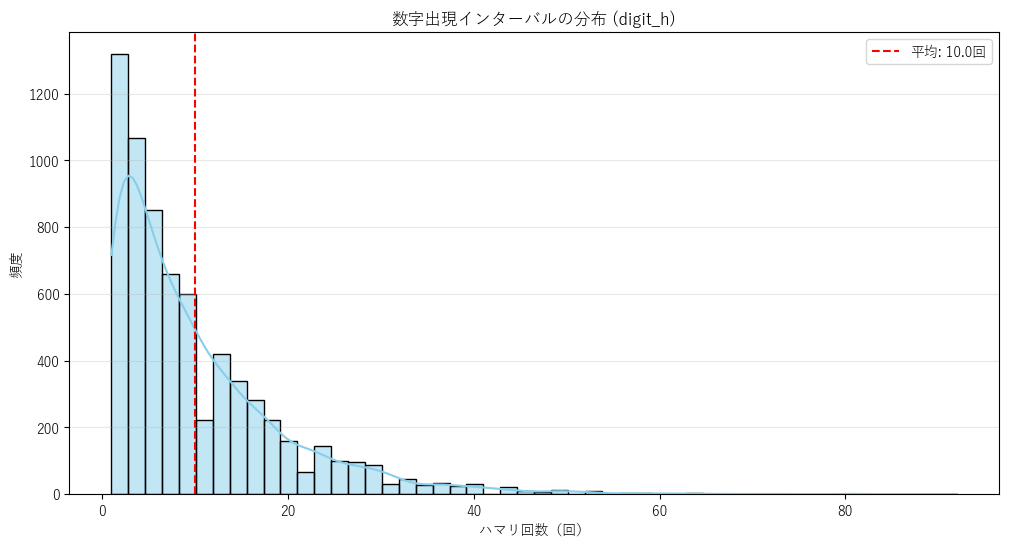

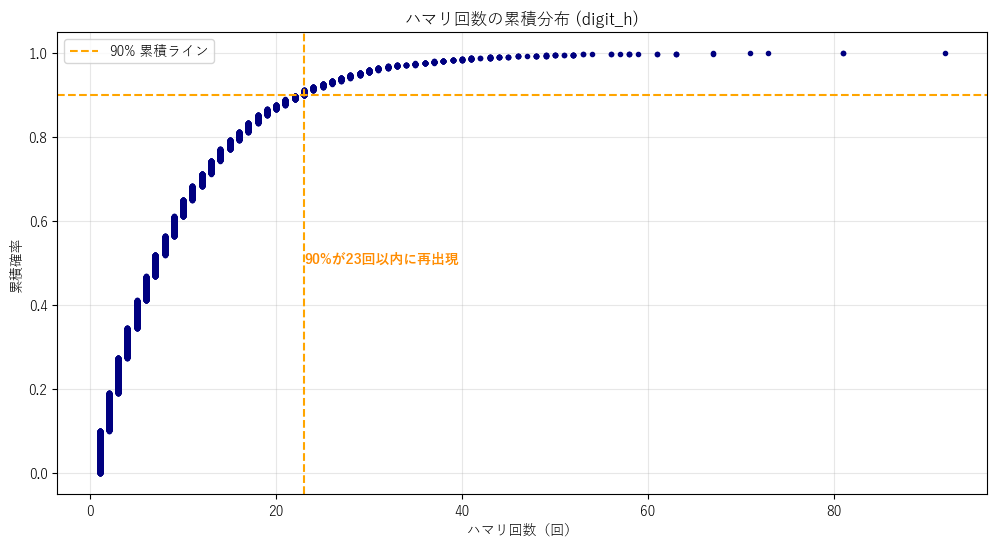

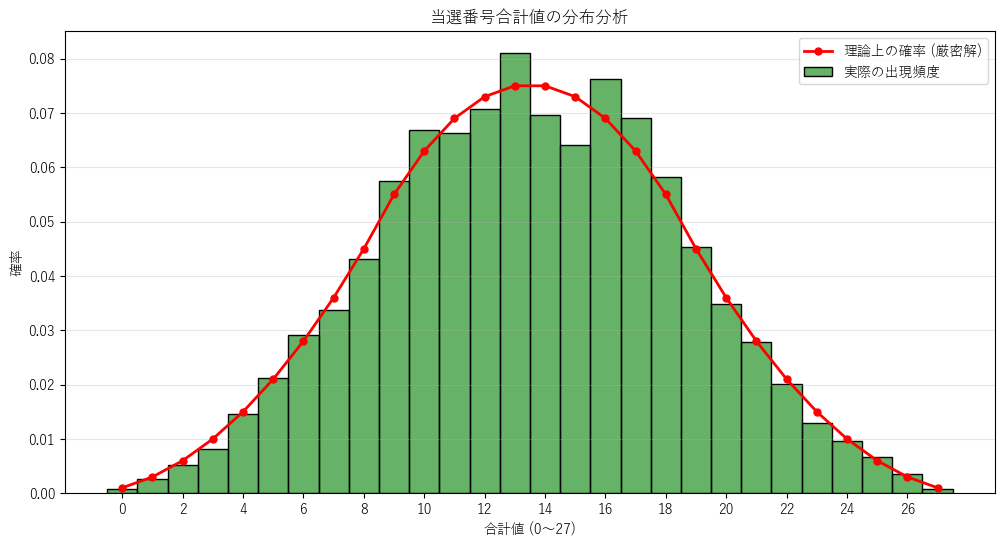

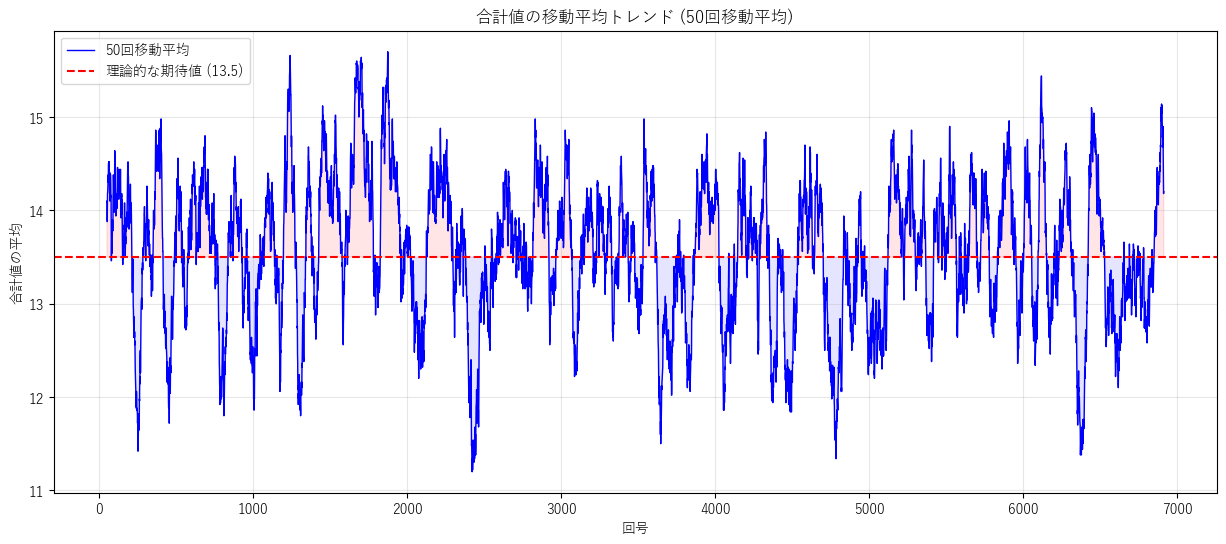

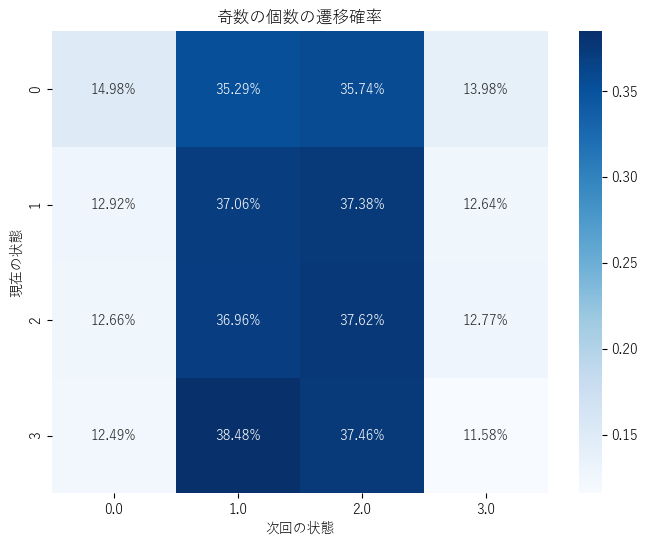

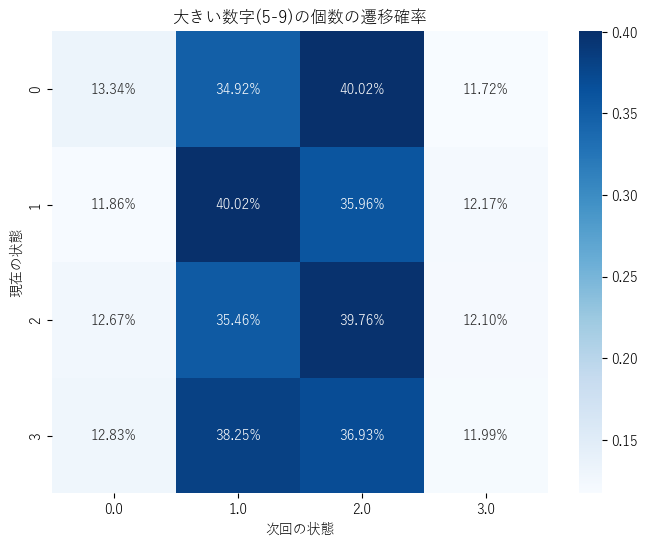

In [10]:
plot_df = features_df

interval_analyzer = Numbers3IntervalAnalyzer(plot_df)
interval_analyzer.plot_interval_analysis(column="digit_h")

trend_analyzer = Numbers3TrendAnalyzer(plot_df)
trend_analyzer.plot_sum_distribution()
trend_analyzer.plot_moving_average_trend(window=50)

pattern_analyzer = Numbers3PatternAnalyzer(plot_df)
pattern_analyzer.plot_transition_heatmap(column="odd_count", title="奇数の個数の遷移確率")
pattern_analyzer.plot_transition_heatmap(column="big_count", title="大きい数字(5-9)の個数の遷移確率")

In [11]:
predictor = Numbers3Predictor(features_df)
predictions = predictor.predict(top_n=10)

print("\n--- 次回出現予測ランキング (TOP 10) ---")
print("解説: 総合スコアは「パターン遷移の確率」「合計値の出やすさ」「ハマり具合(平均回帰)」を組み合わせた指標です。")
predictions

直近の結果: 回号=6914, 番号=388, 奇数=1個, Big=2個

--- 次回出現予測ランキング (TOP 10) ---
解説: 総合スコアは「パターン遷移の確率」「合計値の出やすさ」「ハマり具合(平均回帰)」を組み合わせた指標です。


,予測番号,総合スコア,パターン確率,合計値確率,ハマリ係数,直前ギャップ和,合計,奇数数,Big数
0,256,100.0,0.147384,0.075,1.451086,90,13,1,2
1,257,99.2,0.148629,0.075,1.427667,71,14,2,2
2,716,99.0,0.148629,0.075,1.424850,69,14,2,2
3,851,98.9,0.148629,0.075,1.423411,68,14,2,2
4,752,98.5,0.148629,0.075,1.417439,64,14,2,2
5,554,98.3,0.148629,0.075,1.414313,62,14,2,2
6,815,98.1,0.148629,0.075,1.411087,60,14,2,2
7,356,97.6,0.148629,0.075,1.404305,56,14,2,2
8,850,97.6,0.147384,0.075,1.415888,63,13,1,2
9,616,97.2,0.147384,0.075,1.411087,60,13,1,2


In [12]:
backtester = Numbers3Backtester(features_df, fe, window=200, top_n=100)
bt_results, bt_summary = backtester.run(test_rounds=50, top_k_list=(10, 50, 100))

print("### バックテスト集計 ###")
display(bt_summary)

print("### 直近の検証結果 ###")
display(bt_results.head(10))

直近の結果: 回号=6913, 番号=470, 奇数=1個, Big=1個
直近の結果: 回号=6912, 番号=160, 奇数=1個, Big=1個
直近の結果: 回号=6911, 番号=105, 奇数=2個, Big=1個
直近の結果: 回号=6910, 番号=037, 奇数=2個, Big=1個
直近の結果: 回号=6909, 番号=388, 奇数=1個, Big=2個
直近の結果: 回号=6908, 番号=461, 奇数=1個, Big=1個
直近の結果: 回号=6907, 番号=447, 奇数=1個, Big=1個
直近の結果: 回号=6906, 番号=073, 奇数=2個, Big=1個
直近の結果: 回号=6905, 番号=643, 奇数=1個, Big=1個
直近の結果: 回号=6904, 番号=443, 奇数=1個, Big=0個
直近の結果: 回号=6903, 番号=527, 奇数=2個, Big=2個
直近の結果: 回号=6902, 番号=949, 奇数=2個, Big=2個
直近の結果: 回号=6901, 番号=932, 奇数=2個, Big=1個
直近の結果: 回号=6900, 番号=590, 奇数=2個, Big=2個
直近の結果: 回号=6899, 番号=597, 奇数=3個, Big=3個
直近の結果: 回号=6898, 番号=345, 奇数=2個, Big=1個
直近の結果: 回号=6897, 番号=325, 奇数=2個, Big=1個
直近の結果: 回号=6896, 番号=784, 奇数=1個, Big=2個
直近の結果: 回号=6895, 番号=982, 奇数=1個, Big=2個
直近の結果: 回号=6894, 番号=673, 奇数=2個, Big=2個
直近の結果: 回号=6893, 番号=649, 奇数=1個, Big=2個
直近の結果: 回号=6892, 番号=620, 奇数=0個, Big=1個
直近の結果: 回号=6891, 番号=696, 奇数=1個, Big=3個
直近の結果: 回号=6890, 番号=622, 奇数=0個, Big=1個
直近の結果: 回号=6889, 番号=921, 奇数=2個, Big=1個
直近の結果: 回号=6888, 番号=089, 奇数=1個, Big=2個
直近の結果: 回号=68

,tested,st_top10,st_top50,st_top100,box_top10,box_top50,box_top100
0,50,0,0,3,0,1,6


### 直近の検証結果 ###


,target_round,actual,rank_st,rank_box,st_top10,st_top50,st_top100,box_top10,box_top50,box_top100
0,6914,388,NaN,NaN,False,False,False,False,False,False
1,6913,470,NaN,71.0,False,False,False,False,False,True
2,6912,160,NaN,NaN,False,False,False,False,False,False
3,6911,105,NaN,NaN,False,False,False,False,False,False
4,6910,037,NaN,NaN,False,False,False,False,False,False
5,6909,388,NaN,NaN,False,False,False,False,False,False
6,6908,461,89.0,54.0,False,False,True,False,False,True
7,6907,447,86.0,47.0,False,False,True,False,True,True
8,6906,073,NaN,NaN,False,False,False,False,False,False
9,6905,643,NaN,NaN,False,False,False,False,False,False
